In [1]:
import xarray as xr
import numpy as np
import cftime
import matplotlib.pyplot as plt

In [2]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [3]:
import pop_tools

/global/common/software/m4632/conda/cworthy/lib/python3.11/site-packages/pop_tools/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


In [4]:
xr.set_options(use_new_combine_kwarg_defaults=True)

In [5]:
basins = [
    "North_Atlantic_basin",
    "North_Pacific_basin",
    "South",
    "Southern_Ocean",
]

npolygon = {
    "North_Atlantic_basin": 150,
    "North_Pacific_basin": 200,
    "South": 300,
    "Southern_Ocean": 40,
}

# --- Build forward and reverse maps in one pass ---
polygon_master_map = {}       # (basin, polygon) → index
inverse_polygon_map = {}      # index → (basin, polygon)

idx = 0
for b in basins:
    for p in range(npolygon[b]):
        polygon_master_map[(b, p)] = idx
        inverse_polygon_map[idx] = (b, p)
        idx += 1

In [6]:
def compute_dt_seconds(ds):
    """Return time step length in seconds for each time index."""
    dt = ds.time_bound.isel(d2=1) - ds.time_bound.isel(d2=0)
    dt_seconds = np.array([d.total_seconds() for d in dt.values])
    return xr.DataArray(dt_seconds, dims="time")


def compute_elapsed_days(ds, year0=347):
    """Compute elapsed days since year0-01-01."""
    t0 = cftime.DatetimeNoLeap(year0, 1, 1, 0, 0, 0, 0, has_year_zero=True)
    elapsed = np.array([(t - t0).days for t in ds.time.values])
    return xr.DataArray(elapsed, dims="time", attrs={"units": "days"})


def finalize(arr, ds):
    """Attach elapsed_time coordinate and return cleaned efficiency DataArray."""
    elapsed_days = compute_elapsed_days(ds)
    return arr.assign_coords(elapsed_time=("time", elapsed_days.data))


In [7]:
def open_true_experiment(    
    polygon_id: str,
    intervention_month="01",
    intervention_year="1999",
    year="0347",
):
    
    base_path = "/global/cfs/projectdirs/m4746/Projects/Ocean-CDR-Atlas-v0/data/archive/"
    
    # basin + polygon index lookup
    b, p = inverse_polygon_map[int(polygon_id)]
    
    # build dataset path
    multiplier = f"{int(polygon_id) * 4:05d}"
    subdir = f"smyle.cdr-atlas-v0.glb-dor_{b}_{p:03d}_{intervention_year}-{intervention_month}-01_{multiplier}.001"
    path = f"{base_path}/{subdir}/ocn/hist/*.pop.h.*.nc"

    ds = xr.open_mfdataset(path, decode_timedelta=False)

    return ds

In [45]:
def open_deficit_tracer_experiment(
    suffix,
    intervention_month="01",
    intervention_year="1999",
    year="0347"
):
        
    output_dir = f"/global/cfs/cdirs/m4746/Users/nora/Ocean-CDR-Atlas-v0/data/archive/smyle.anti-tracer.glb-antitracer_{intervention_year}-{intervention_month}_{suffix}.001/ocn/hist/"
    path = f"{output_dir}/smyle.anti-tracer.glb-antitracer_1999-01_{suffix}.001.pop.h.{year}-**.nc"
    print(path)
    ds = xr.open_mfdataset(path, decode_timedelta=False)

    return ds

In [46]:
def compute_forcing(ds, flux, cumulative=True):

    dt = compute_dt_seconds(ds)
    forcing = ds[flux] * dt

    if cumulative:
        forcing = forcing.cumsum("time")

    return forcing.where(ds.KMT > 0)

In [47]:
def compute_air_sea_flux(ds, flux1, flux2, cumulative=True):
    """Compute change in DIC inventory"""

    dt = compute_dt_seconds(ds)
    delta_dic = -(ds[flux1] - ds[flux2]) * dt

    if cumulative:
        delta_dic = delta_dic.cumsum("time")

    return delta_dic.where(ds.KMT > 0)

In [48]:
def compute_spatial_integral(da, ds):

    da = (da * ds.TAREA).sum(["nlat", "nlon"])

    return da

In [49]:
import matplotlib

def get_colors(ids, cmap_name="Paired"):
    cmap = matplotlib.colormaps.get_cmap(cmap_name)
    N = len(ids)
    colors = [cmap(i / N) for i in range(N)]
    return dict(zip(ids, colors))

In [50]:
def _add_coastlines_and_gridlines(ax):    
    # Add coastlines and land
    ax.coastlines()
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
    
    # Gridlines with labels only on left and bottom
    gl = ax.gridlines(
        draw_labels=True,
        linewidth=0.5,
        color="gray",
        x_inline=False,
        y_inline=False
    )
    gl.top_labels = False
    gl.right_labels = False

In [51]:
import xarray as xr
from matplotlib.colors import ListedColormap, BoundaryNorm
import numpy as np

def plot_polygons(suffix, ids, color_map):
    ds = open_deficit_tracer_experiment(suffix=suffix)

    # Initialize mask with zeros for ocean
    mask = xr.full_like(ds[f"ANTITRACER{ids[0]}_FORCING"].isel(time=0), 0, dtype=int)
    
    # Assign each polygon a unique integer
    for i, polygon_id in enumerate(ids):
        mask += xr.where(
            ds[f"ANTITRACER{polygon_id}_FORCING"].isel(time=0) > 0,
            i + 1,
            0
        )

    # Set land cells (KMT==0) to NaN
    mask = mask.where(ds.KMT > 0, np.nan)

    # Colors: first entry is ocean (0), then polygon colors, land (NaN) handled via set_bad
    colors = ["white"] + [color_map[i] for i in ids]
    cmap = ListedColormap(colors)
    #cmap.set_bad("gray")  # Land cells (NaN) will appear gray

    # Norm for discrete values: 0 (ocean), 1..N polygons
    bounds = np.arange(0, len(ids) + 2) - 0.5
    norm = BoundaryNorm(bounds, ncolors=len(colors))

    grid = pop_tools.get_grid("POP_gx1v7")
    # Plot
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={"projection": ccrs.PlateCarree()})
    p = ax.pcolormesh(
        grid.TLONG,
        grid.TLAT,
        mask,
        cmap=cmap,
        norm=norm,
        transform=ccrs.PlateCarree()
    )
    ax.set_title("Polygons")
    _add_coastlines_and_gridlines(ax)


## Polygons

In [52]:
ids = ["000", "001", "150", "151", "350", "351", "651", "655"]

In [53]:
colors = get_colors(ids)

In [54]:
plot_polygons("all", ids, colors)

/global/cfs/cdirs/m4746/Users/nora/Ocean-CDR-Atlas-v0/data/archive/smyle.anti-tracer.glb-antitracer_1999-01_all.001/ocn/hist//smyle.anti-tracer.glb-antitracer_1999-01_all.001.pop.h.0347-**.nc


OSError: no files to open

## Efficiency curves

In [18]:
def compute_true_efficiency(
    polygon_id: str,
    intervention_month="01",
    intervention_year="1999",
    year="0347",
):

    ds = open_true_experiment(polygon_id, intervention_month, intervention_year, year)

    forcing = compute_spatial_integral(compute_forcing(ds, "DIC_FLUX"), ds)
    delta_dic = compute_spatial_integral(compute_air_sea_flux(ds, "FG_CO2", "FG_ALT_CO2"), ds)
    
    eff = delta_dic / forcing
    
    return finalize(eff, ds)

In [19]:
def compute_approx_efficiency(
    polygon_id: str,
    intervention_month="01",
    intervention_year="1999",
    year="0347",
):

    ds = open_deficit_tracer_experiment(intervention_month, intervention_year, year)

    forcing = - compute_spatial_integral(compute_forcing(ds, f"ANTITRACER{polygon_id}_FORCING"), ds)
    delta_dic = - compute_spatial_integral(compute_air_sea_flux(ds, f"STF_ANTITRACER{polygon_id}", f"ANTITRACER{polygon_id}_FORCING"), ds)
    
    eff = delta_dic / forcing
    
    return finalize(eff, ds)

In [20]:
def compare_efficiency_curves(polygon_id, color="orange"):
    eff = compute_true_efficiency(polygon_id)  
    eff_tilde = compute_approx_efficiency(polygon_id)

    fig, ax = plt.subplots()
    
    # Light gray background
    ax.set_facecolor("#f0f0f0")  # or any light gray like 'lightgray'

    ax.plot(eff.elapsed_time, eff.squeeze(), label="CESM-MARBL", lw=3, color="k")
    ax.plot(eff_tilde.elapsed_time, eff_tilde, label="CESM", lw=2, color=color)

    ax.legend()
    ax.grid(True, which="both", linestyle="--", linewidth=0.5, color="white")

    ax.set_title(f"Polygon ID: {polygon_id}")
    ax.set_xlabel("Days")
    ax.set_ylabel("Efficiency")
    ax.set_ylim([0, 1])
    
    return fig

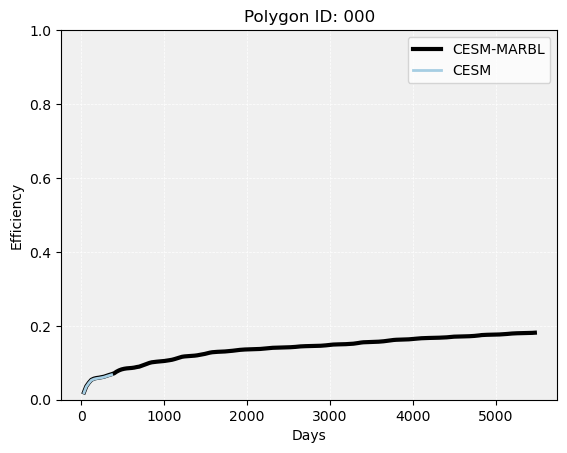

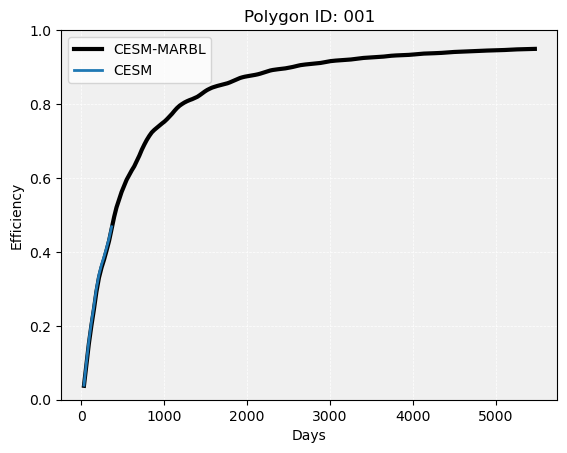

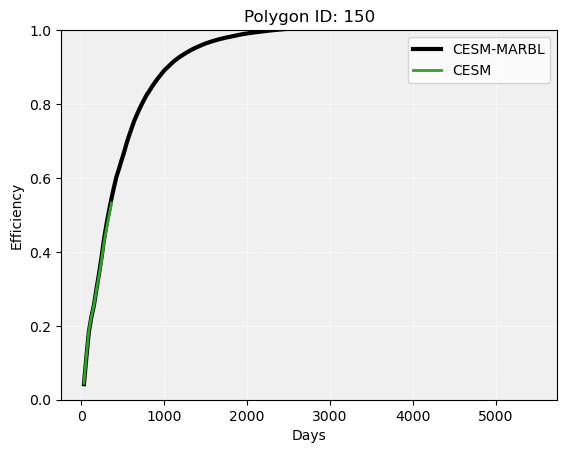

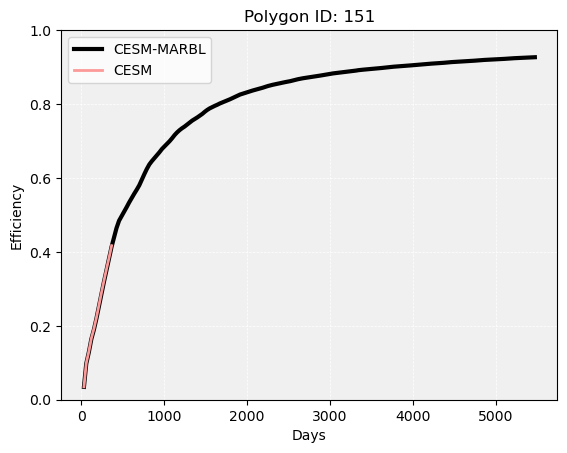

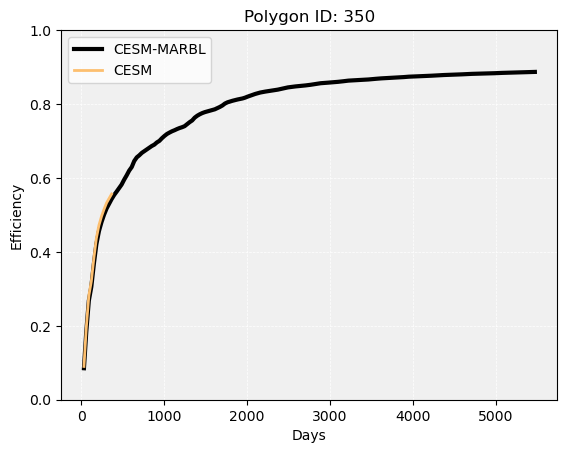

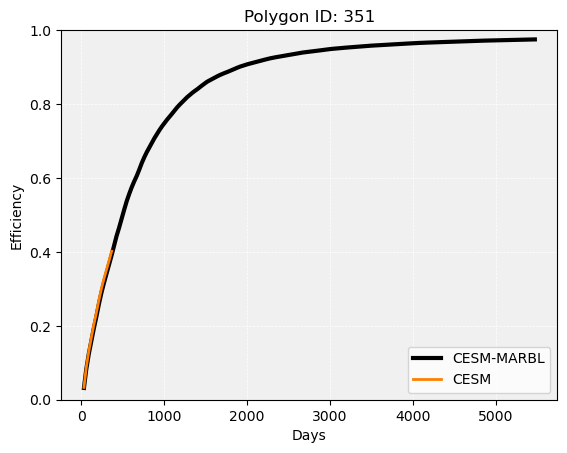

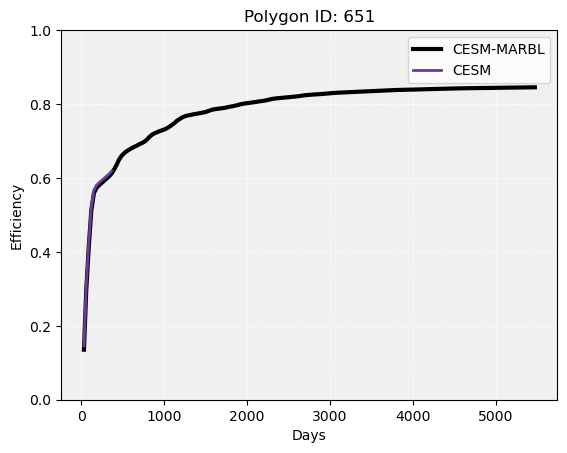

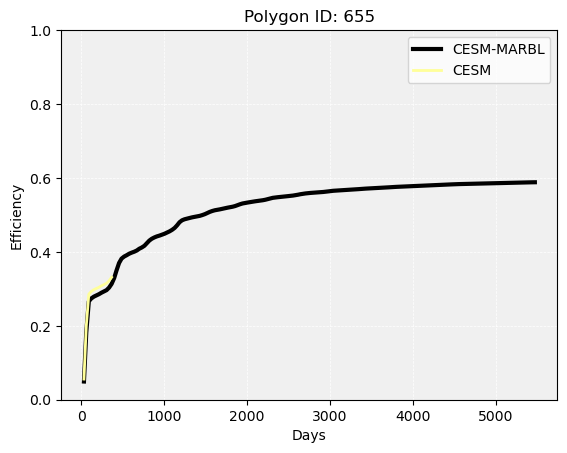

In [21]:
for polygon_id in ids:
    color = colors[polygon_id]
    fig = compare_efficiency_curves(polygon_id, color)
    fig.savefig(
        f"figures/uptake_curves_{polygon_id}.png",
        dpi=300,
        bbox_inches="tight",
    )

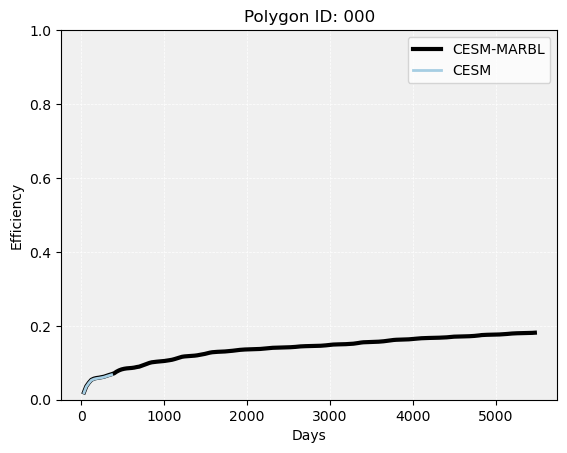

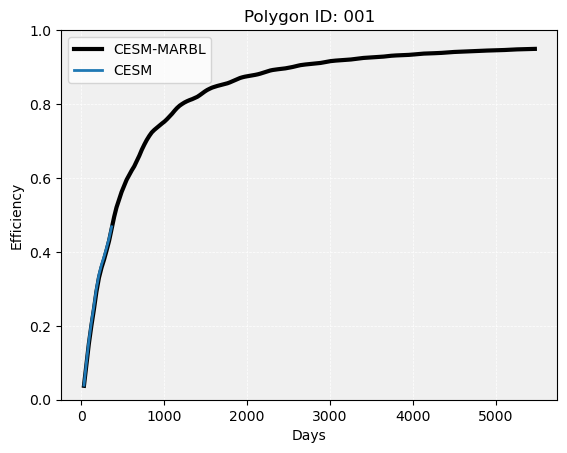

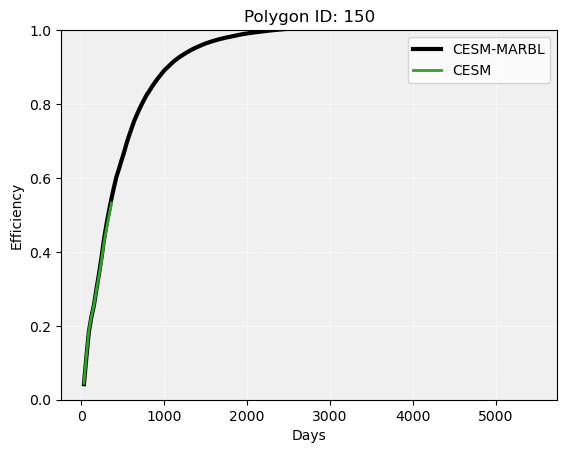

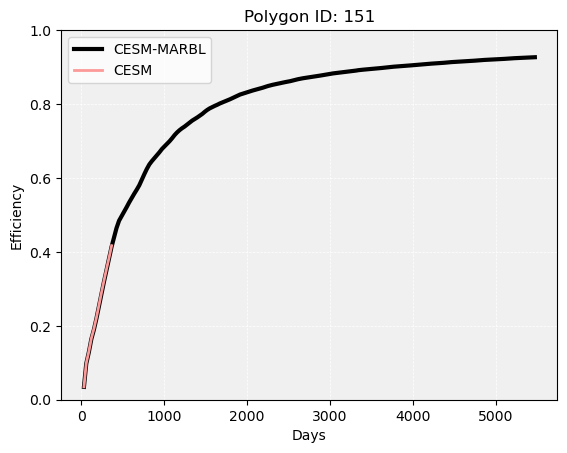

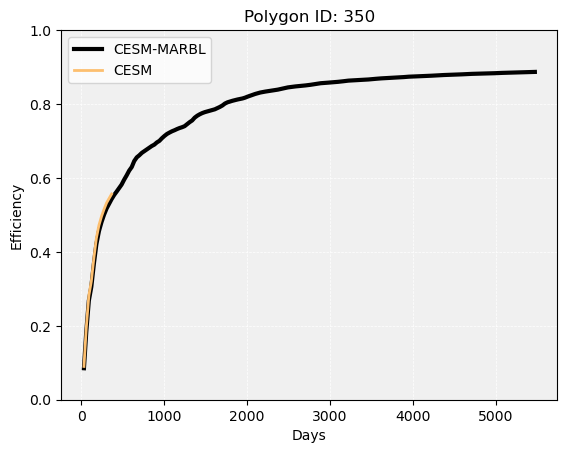

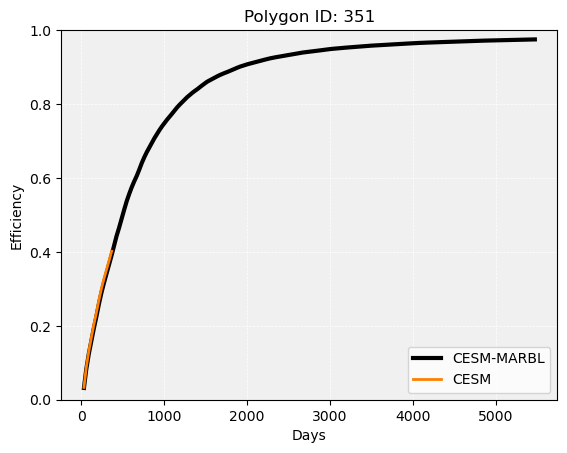

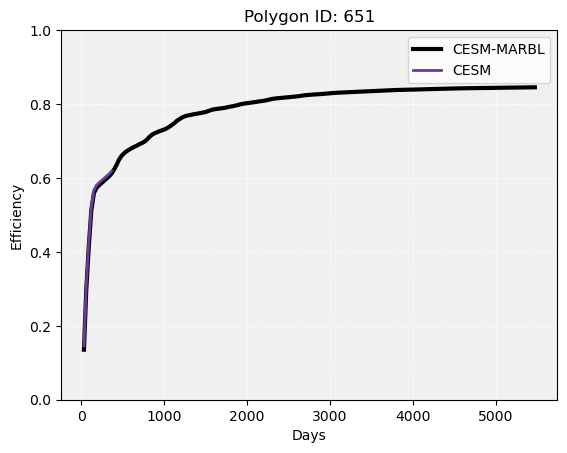

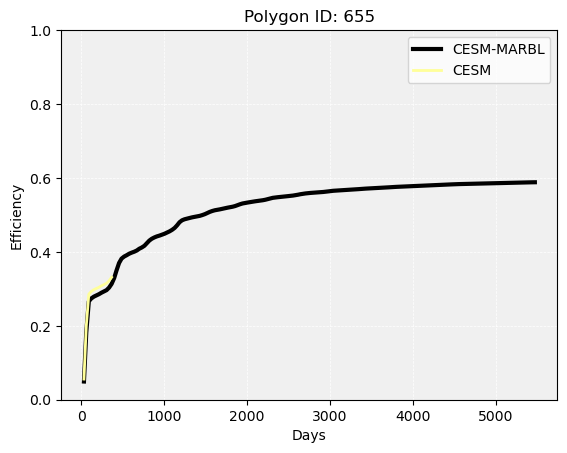

In [164]:
for polygon_id in ids:
    color = colors[polygon_id]
    fig = compare_efficiency_curves(polygon_id, color)
    fig.savefig(
        f"figures/uptake_curves_{polygon_id}.png",
        dpi=300,
        bbox_inches="tight",
    )

## Air-sea flux

In [14]:
def compute_true_flux(
    polygon_id: str,
    cumulative=True,
    spatial_integral=False
):

    ds = open_true_experiment(polygon_id)
    delta_dic = compute_air_sea_flux(ds, "FG_CO2", "FG_ALT_CO2", cumulative)

    if spatial_integral:
        delta_dic = compute_spatial_integral(delta_dic, ds)
        
    return finalize(delta_dic, ds)

In [17]:
def compute_approx_flux(
    polygon_id: str,
    cumulative=True,
    spatial_integral=False
):

    ds = open_deficit_tracer_experiment()
    delta_dic = - compute_air_sea_flux(ds, f"STF_ANTITRACER{polygon_id}", f"ANTITRACER{polygon_id}_FORCING", cumulative)

    if spatial_integral:
        delta_dic = compute_spatial_integral(delta_dic, ds)
        
    return finalize(delta_dic, ds)

### Spatial comparisons

In [45]:
def compare_air_sea_flux(polygon_id, time, cumulative=True):

    true_flux = compute_true_flux(polygon_id, cumulative).isel(time=time)
    approx_flux = compute_approx_flux(polygon_id, cumulative).isel(time=time)
    
    fig, axs = plt.subplots(1, 3, figsize=(20, 4))
    
    vmin = min(true_flux.min().values, approx_flux.min().values)
    cmap = plt.get_cmap("PuBuGn_r").copy()
    cmap.set_bad(color="gray")
    kwargs = {"vmin": vmin, "vmax": 0, "cmap": cmap}
    
    true_flux.plot(ax=axs[0], **kwargs)
    axs[0].set_title("CESM-MARBL")
    
    approx_flux.plot(ax=axs[1], **kwargs)
    axs[1].set_title("CESM")
    
    (true_flux - approx_flux).plot(ax=axs[2])
    axs[2].set_title("Difference")

    title = "Air-sea flux"
    if cumulative:
        title = "Cumulative " + title
        
    fig.suptitle(f"{title}, elapsed time: {true_flux.elapsed_time.item()} days", y=1.05)
    return fig


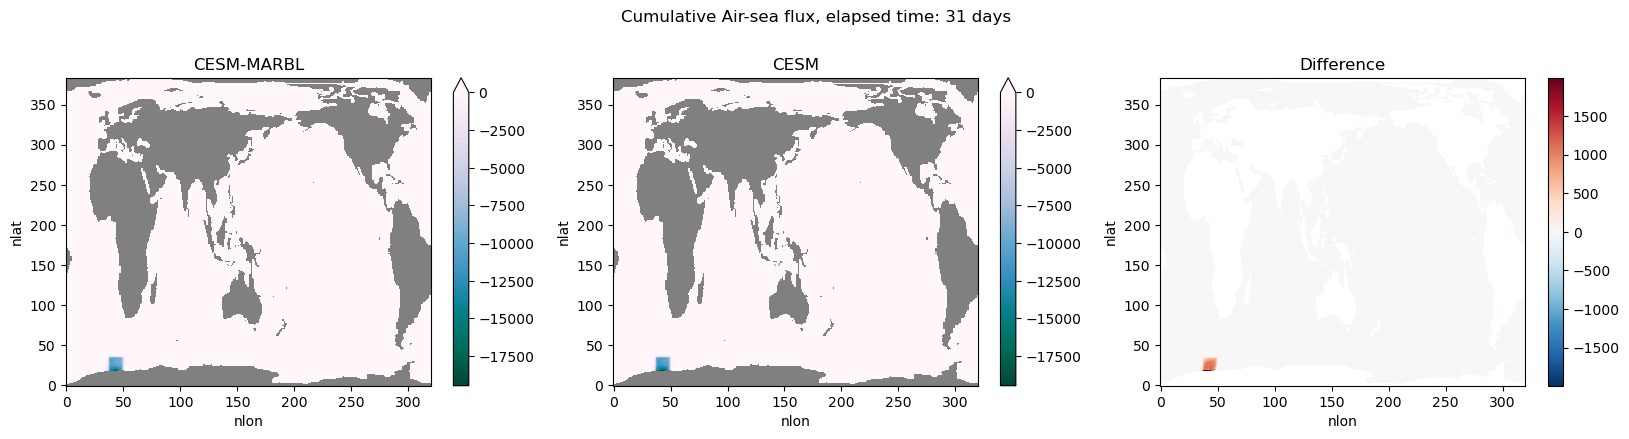

In [83]:
fig = compare_air_sea_flux("651", 0)

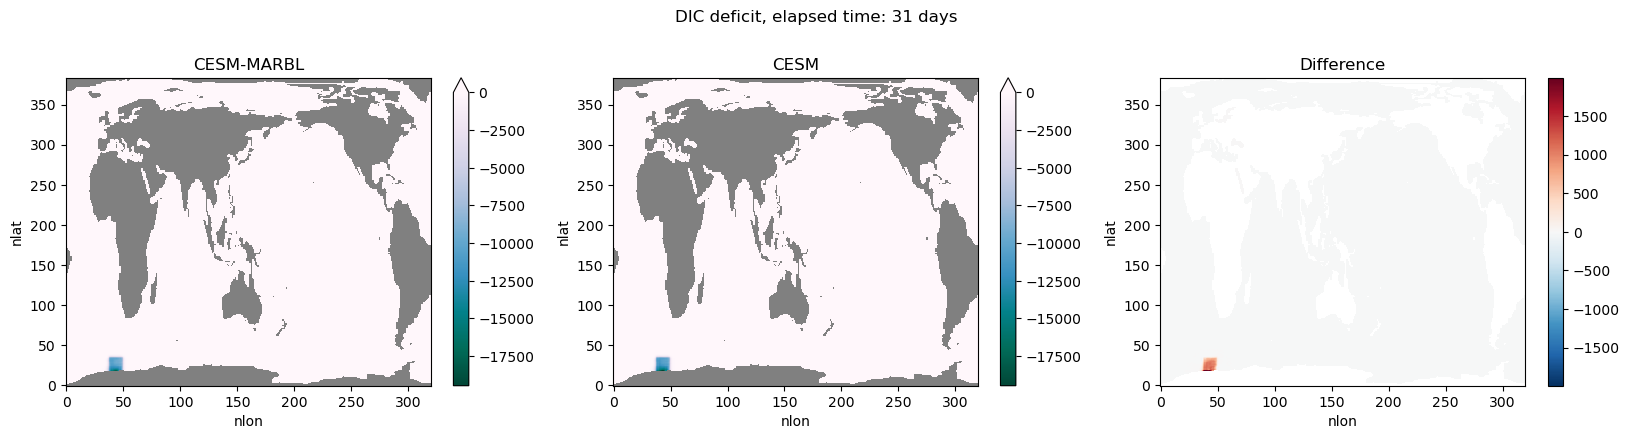

In [62]:
fig = compare_air_sea_flux("651", 0, False)

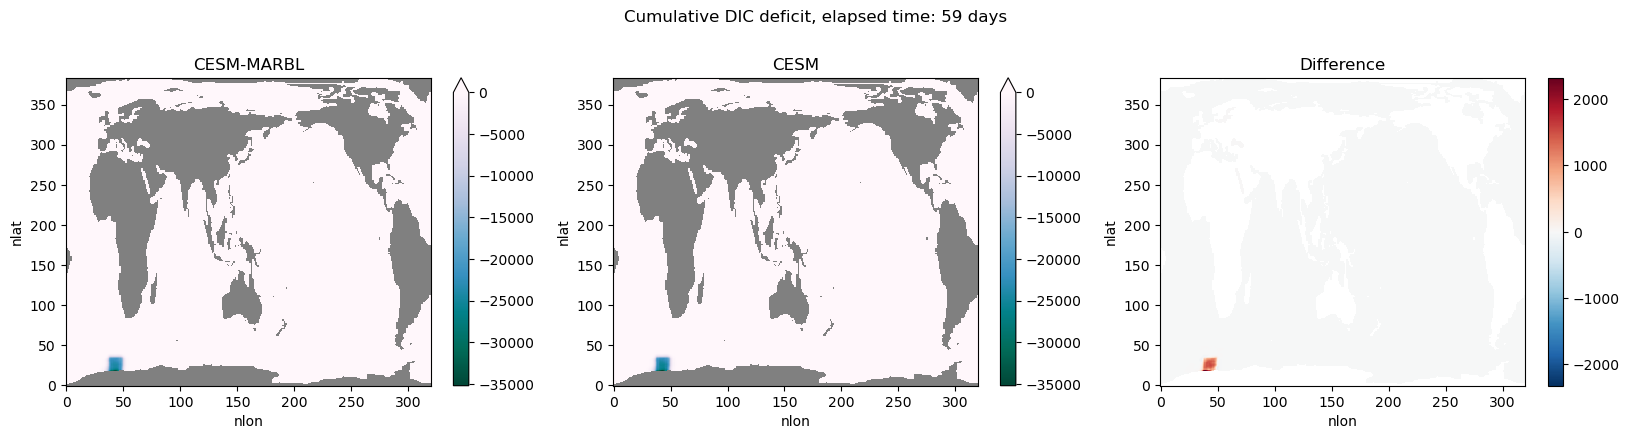

In [63]:
fig = compare_air_sea_flux("651", 1)

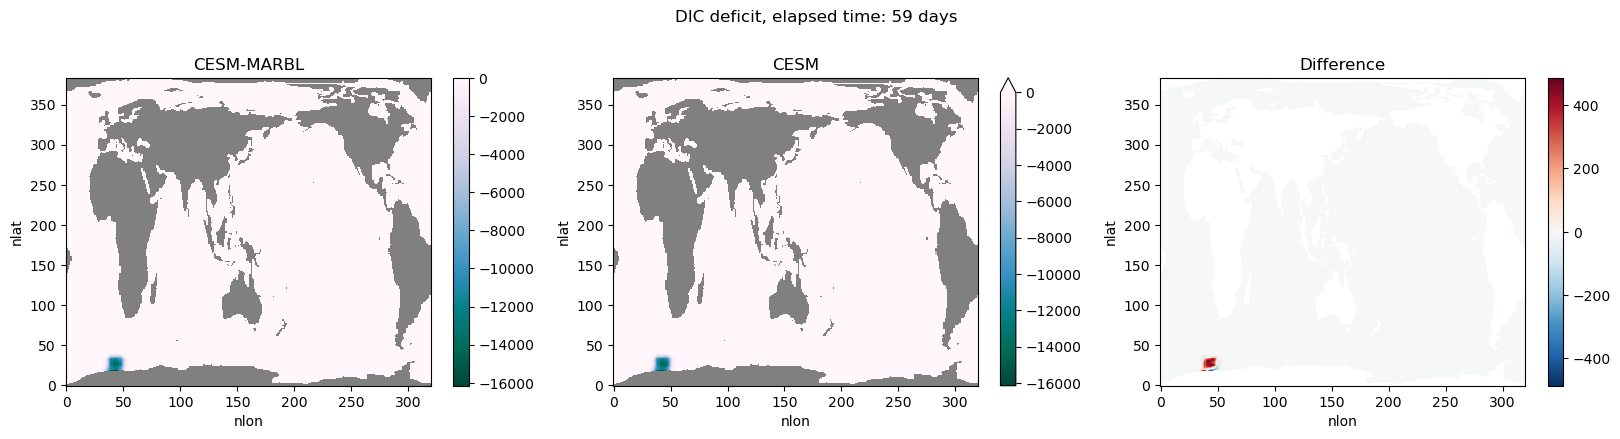

In [64]:
fig = compare_air_sea_flux("651", 1, False)

In [ ]:
fig = compare_air_sea_flux("651", 2)

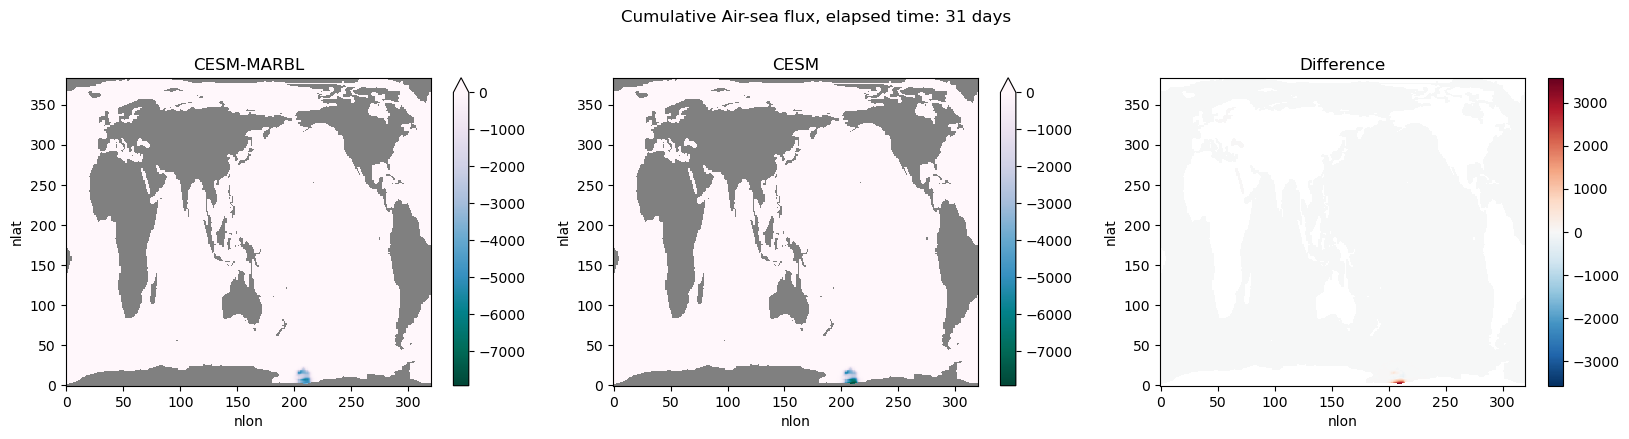

In [46]:
fig = compare_air_sea_flux("655", 0)

In [54]:
fig = compare_air_sea_flux("655", 1)

OSError: no files to open

### Spatially integrated

In [36]:
def compare_air_sea_flux_spatially_integrated(polygon_id, cumulative=True):
    
    true_flux = compute_true_flux(polygon_id, cumulative, True)
    approx_flux = compute_approx_flux(polygon_id, cumulative, True)

    fig, ax = plt.subplots()
    
    ax.plot(true_flux.elapsed_time, true_flux, "-o", label="CESM-MARBL", lw=2)
    ax.plot(approx_flux.elapsed_time, approx_flux, "-o", label="CESM", lw=2)

    ax.legend()
    ax.grid()

    ax.set_title(f"Polygon ID: {polygon_id}")
    ax.set_xlabel("Days")
    ax.set_xlim([0, 366])
    
    title = "Air-sea flux"
    if cumulative:
        title = "Cumulative " + title
        
    ax.set_ylabel(title)
    
    return fig

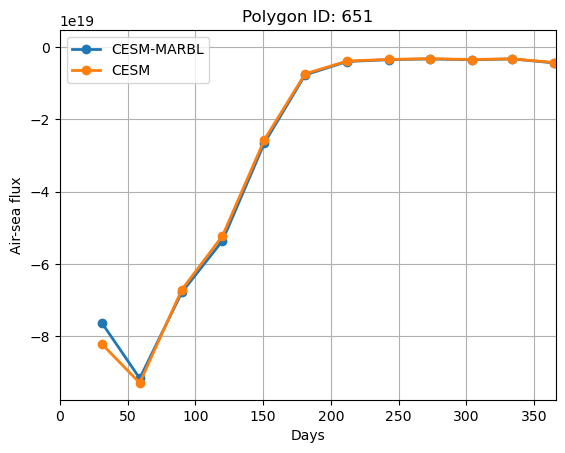

In [37]:
fig = compare_air_sea_flux_spatially_integrated("651", False)

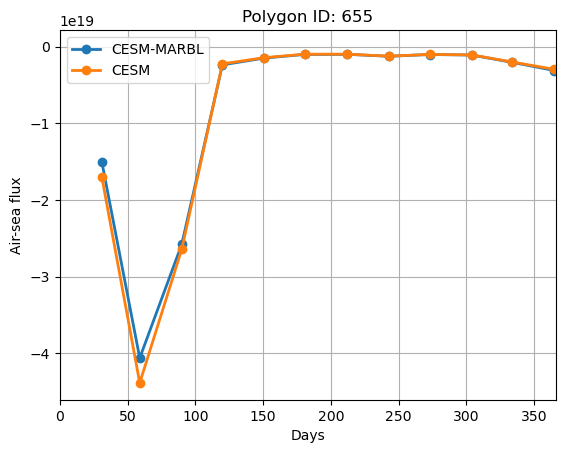

In [38]:
fig = compare_air_sea_flux_spatially_integrated("655", False)

### Forcing

In [39]:
def compute_true_forcing(
    polygon_id: str,
    cumulative=True,
    spatial_integral=False
):

    ds = open_true_experiment(polygon_id)

    forcing = compute_forcing(ds, "DIC_FLUX", cumulative)
    if spatial_integral:
        forcing = compute_spatial_integral(forcing, ds)
        
    return finalize(forcing, ds)

In [40]:
def compute_approx_forcing(
    polygon_id: str,
    cumulative=True,
    spatial_integral=False
):

    ds = open_deficit_tracer_experiment()

    forcing = - compute_forcing(ds, f"ANTITRACER{polygon_id}_FORCING", cumulative)
    if spatial_integral:
        forcing = compute_spatial_integral(forcing, ds)
    
    return finalize(forcing, ds)

### Spatial plots

In [75]:
def compare_forcing(polygon_id, time, cumulative=True):

    true_forcing = compute_true_forcing(polygon_id, cumulative).isel(time=time)
    approx_forcing = compute_approx_forcing(polygon_id, cumulative).isel(time=time)
    
    fig, axs = plt.subplots(1, 3, figsize=(20, 4))
    
    vmin = min(true_forcing.min().values, approx_forcing.min().values)
    cmap = plt.get_cmap("PuBuGn_r").copy()
    cmap.set_bad(color="gray")
    kwargs = {"vmin": vmin, "vmax": 0, "cmap": cmap}
    
    true_forcing.plot(ax=axs[0], **kwargs)
    axs[0].set_title("CESM-MARBL")
    
    approx_forcing.plot(ax=axs[1], **kwargs)
    axs[1].set_title("CESM")
    
    (true_forcing - approx_forcing).plot(ax=axs[2])
    axs[2].set_title("Difference")

    title = "Forcing"
    if cumulative:
        title = "Cumulative " + title
        
    fig.suptitle(f"{title}, elapsed time: {true_forcing.elapsed_time.item()} days", y=1.05)

    return fig


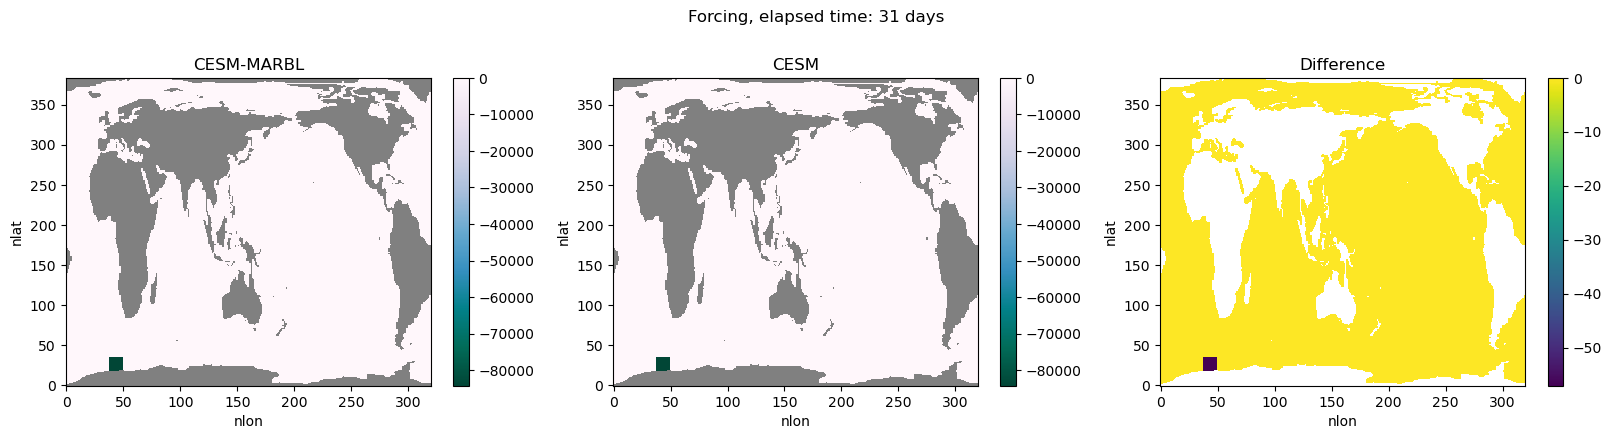

In [76]:
fig = compare_forcing("651", 0, False)

In [79]:
50/80000

0.000625

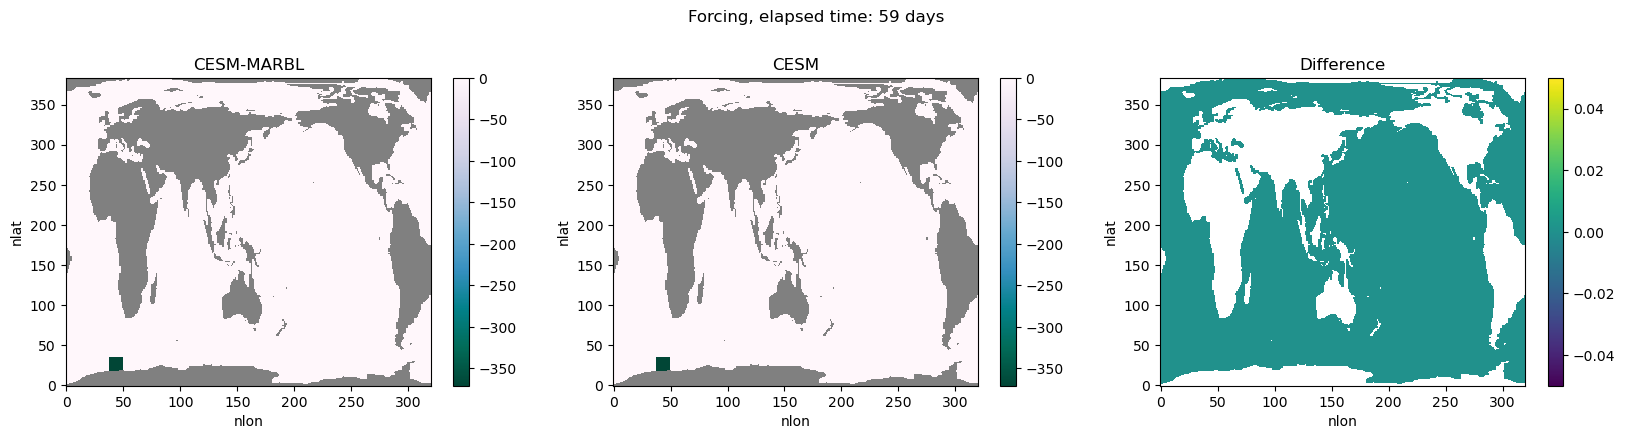

In [77]:
fig = compare_forcing("651", 1, False)

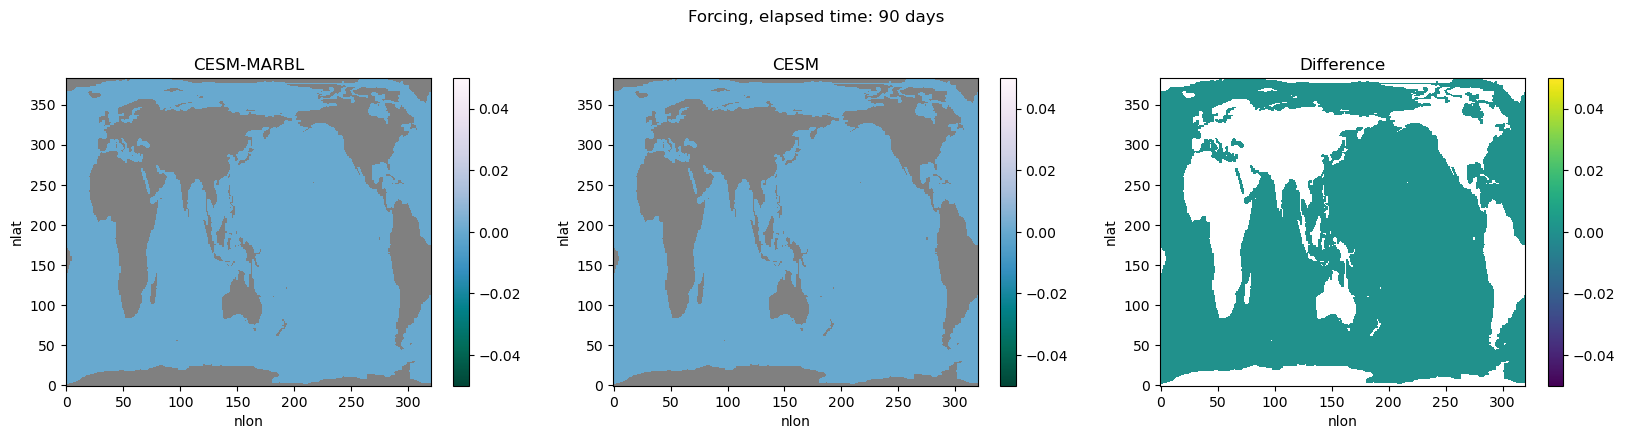

In [78]:
fig = compare_forcing("651", 2, False)

### Spatial integral

In [41]:
def compare_forcing_spatially_integrated(polygon_id, cumulative=True):
    
    true_forcing = compute_true_forcing(polygon_id, cumulative, True)
    approx_forcing = compute_approx_forcing(polygon_id, cumulative, True)

    fig, ax = plt.subplots()
    
    ax.plot(true_forcing.elapsed_time, true_forcing, "-o", label="CESM-MARBL", lw=2)
    ax.plot(approx_forcing.elapsed_time, approx_forcing, "-o", label="CESM", lw=2)

    ax.legend()
    ax.grid()

    ax.set_title(f"Polygon ID: {polygon_id}")
    ax.set_xlabel("Days")
    ax.set_xlim([0, 366])
    
    title = "Forcing"
    if cumulative:
        title = "Cumulative " + title
        
    ax.set_ylabel(title)
    
    return fig

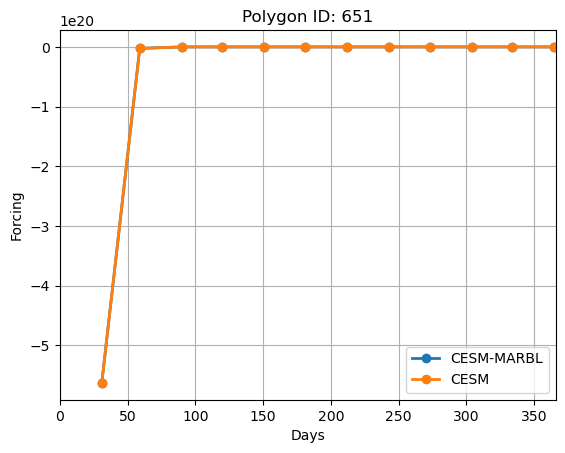

In [42]:
fig = compare_forcing_spatially_integrated("651", False)

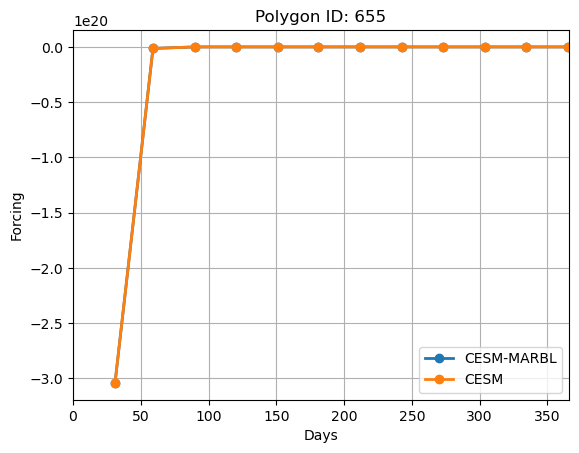

In [43]:
fig = compare_forcing_spatially_integrated("655", False)

## Beta

In [47]:
ds = xr.open_dataset("/global/cfs/projectdirs/m4746/Projects/OAE-Efficiency-Map/data/beta/carbonate_sensitivity.nc")

In [48]:
ds

<xarray.Dataset> Size: 8GB
Dimensions:    (time: 8395, Y: 384, X: 320, d2: 2)
Coordinates:
  * Y          (Y) int32 2kB 1 2 3 4 5 6 7 8 ... 377 378 379 380 381 382 383 384
  * X          (X) int32 1kB 1 2 3 4 5 6 7 8 ... 313 314 315 316 317 318 319 320
    TLAT       (Y, X) float64 983kB ...
    TLONG      (Y, X) float64 983kB ...
  * time       (time) object 67kB 1998-01-01 12:00:00 ... 2020-12-31 12:00:00
    time_bnds  (time, d2) object 134kB ...
Dimensions without coordinates: d2
Data variables:
    dDICdCO2   (time, Y, X) float64 8GB ...

In [51]:
ds.dDICdCO2.min()

<xarray.DataArray 'dDICdCO2' ()> Size: 8B
array(1.29309292)